**# Walmart Black Friday Analysis**

***PROBLEM STATEMENT***:- **In this project,  Aim is to analyse Walmart's Black Friday sales data to understand how factors such as gender, age, marital status, city category, occupation, and product category influence customer purchase amounts. I will perform exploratory data analysis to identify trends and patterns in the data and use confidence intervals based on the Central Limit Theorem (CLT) to compare the average spending of different customer groups**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set(style="whitegrid")

plt.rcParams["figure.figsize"]=(8,5)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving walmart_data.csv to walmart_data.csv


In [ ]:
df = pd.read_csv("walmart_data.csv")

**DATA TYPES OF WALMART SHEET AND CHARACTERISTICS LIKE DATA TYPE , DUPLICATE AND UNIQUE VALUES, SHAPE ETC..**.

In [ ]:
import glob

csv_files = glob.glob("*.csv")

print(csv_files)

df = pd.read_csv(csv_files[0])

df.head()

['walmart_data.csv']


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [ ]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 550068
Columns : 10


In [ ]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [ ]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("----------------")

User_ID
5891
----------------
Product_ID
3631
----------------
Gender
2
----------------
Age
7
----------------
Occupation
21
----------------
City_Category
3
----------------
Stay_In_Current_City_Years
5
----------------
Marital_Status
2
----------------
Product_Category
20
----------------
Purchase
18105
----------------


**NON GRAPHICAL ANALYSIS**

**Number of Unique Values in Each Column**

In [ ]:
df.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


Columns such as Gender, Age, City_Category, Marital_Status, and Product_Category have a limited number of unique values, making them suitable for categorical analysis.

**Gender Distribution**

In [ ]:
df["Gender"].value_counts()

,count
Gender,
M,414259
F,135809


The dataset contains both male and female customers, with males forming the larger group.

**Age Distribution**

In [ ]:
df["Age"].value_counts().sort_index()

,count
Age,
0-17,15102
18-25,99660
26-35,219587
36-45,110013
46-50,45701
51-55,38501
55+,21504


The 26–35 age group has the highest number of customers

**City Category Distribution**

In [ ]:
df["City_Category"].value_counts()

,count
City_Category,
B,231173
C,171175
A,147720


Customers belong to all three city categories, with City Category B having the highest representation

**Marital Status Distribution**

In [ ]:
df["Marital_Status"].value_counts()

,count
Marital_Status,
0,324731
1,225337


Both married and unmarried customers are well represented in the dataset.

**Occupation Distribution**

In [ ]:
df["Occupation"].value_counts().sort_index()

,count
Occupation,
0,69638
1,47426
2,26588
3,17650
4,72308
5,12177
6,20355
7,59133
8,1546


Customers belong to a wide range of occupations


**Purchase Summary**



In [ ]:
df["Purchase"].describe()

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


Purchase amounts vary considerably, with an average purchase of around ₹9,261 and values ranging from ₹12 to ₹23,961.

**VISUAL ANALYSIS**

Purchase Distribution

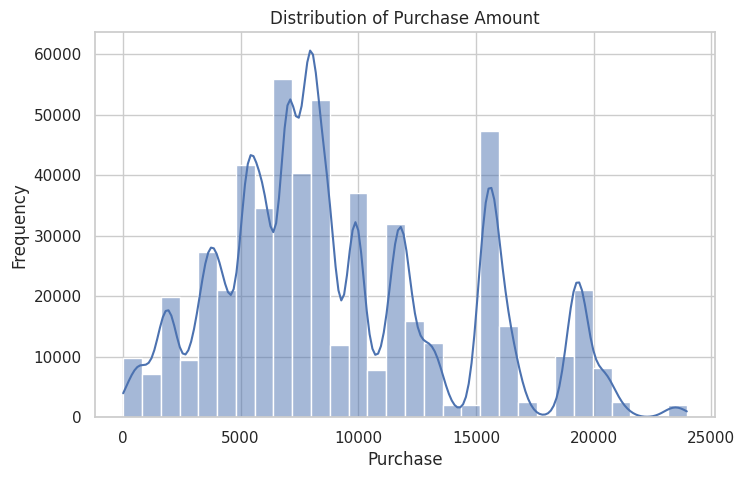

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Purchase"], bins=30, kde=True)

plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase")
plt.ylabel("Frequency")

plt.show()

Purchase amounts are positively skewed, with most transactions occurring at lower purchase values.

GENDER DISTRIBUTION

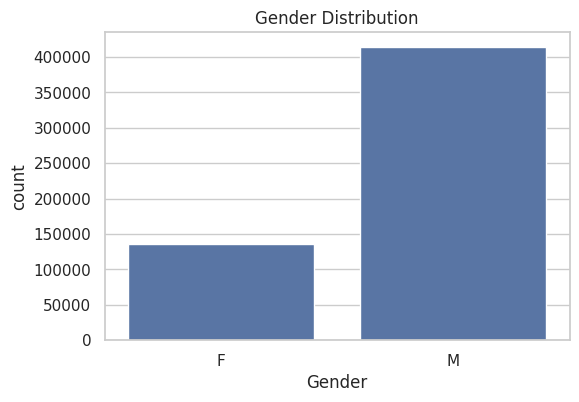

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

Male customers outnumber female customers.

**Age Distribution**

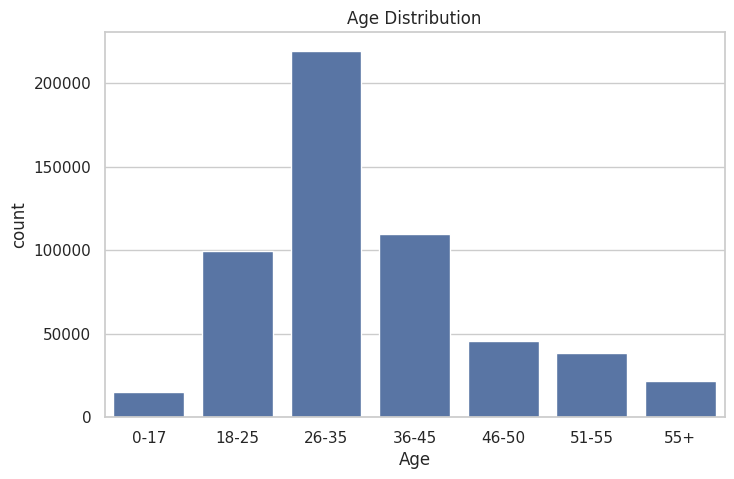

In [ ]:
age_order = ["0-17","18-25","26-35","36-45","46-50","51-55","55+"]

plt.figure(figsize=(8,5))

sns.countplot(x="Age", data=df, order=age_order)

plt.title("Age Distribution")

plt.show()

The 26–35 age group has the highest number of customers.

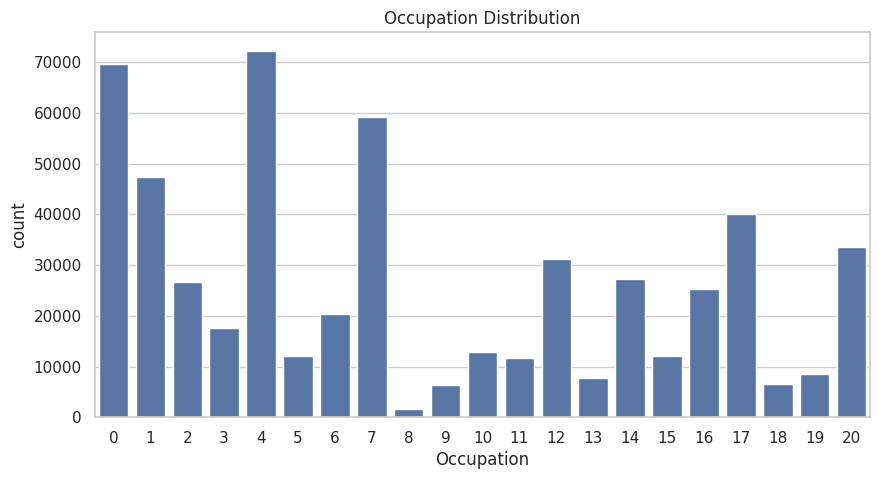

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(x="Occupation", data=df)

plt.title("Occupation Distribution")

plt.show()

Customers belong to diverse occupations, with some occupations having significantly more customers.

**City Category Distribution**

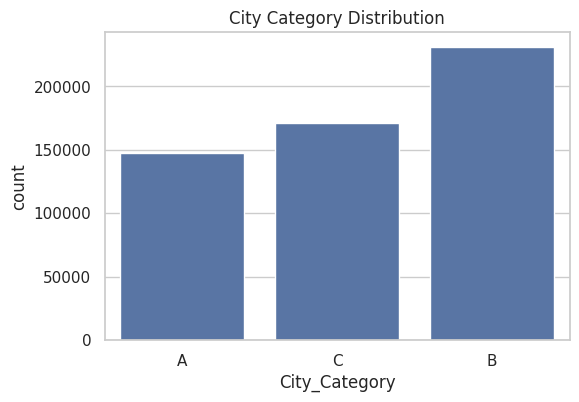

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="City_Category", data=df)

plt.title("City Category Distribution")

plt.show()

City Category B has the highest customer count.

**Marital Status Distribution**

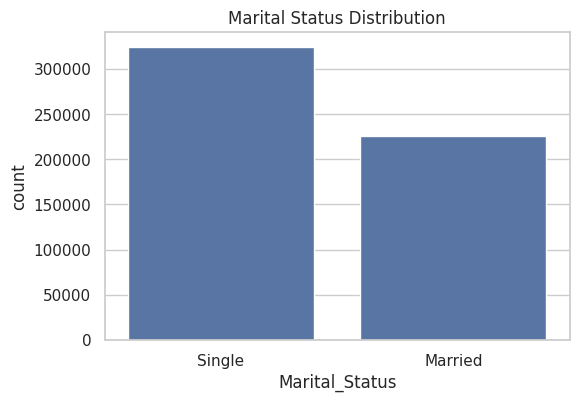

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Marital_Status"].map({0:"Single",1:"Married"})
)

plt.title("Marital Status Distribution")

plt.show()

Both married and unmarried customers are well represented.

**Purchase Boxplot**

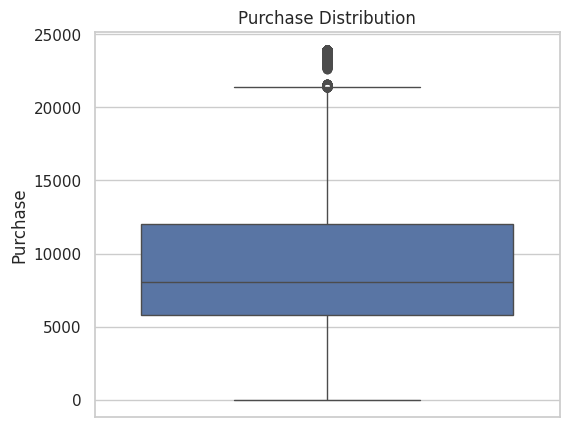

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(y="Purchase", data=df)

plt.title("Purchase Distribution")

plt.show()

Purchase values contain several high-value outliers.

**Gender vs Purchase (Boxplot)**

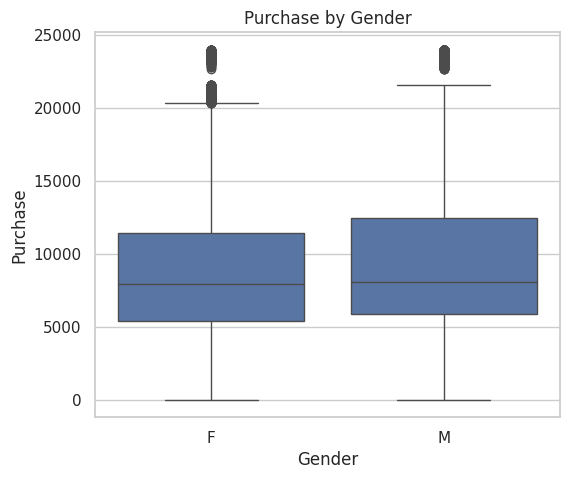

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="Gender",
    y="Purchase",
    data=df
)

plt.title("Purchase by Gender")

plt.show()

Male customers spend slightly more than female customers on average.

**Age vs Purchase (Boxplot)**

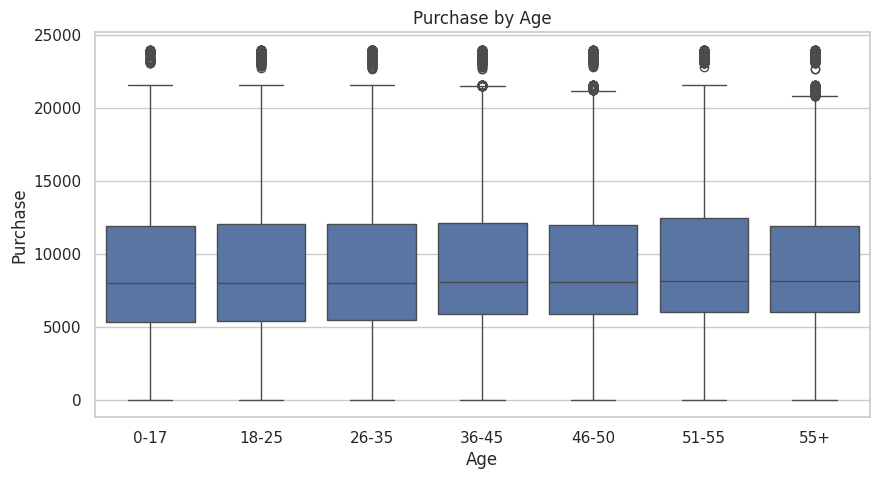

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Age",
    y="Purchase",
    data=df,
    order=age_order
)

plt.title("Purchase by Age")

plt.show()

Customers aged 26–35 generally have higher purchase amounts.

**Marital Status vs Purchase**

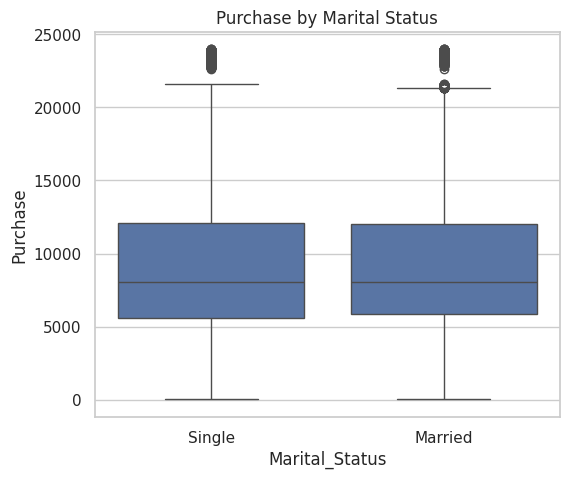

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x=df["Marital_Status"].map({0:"Single",1:"Married"}),
    y=df["Purchase"]
)

plt.title("Purchase by Marital Status")

plt.show()

Spending patterns are similar for married and unmarried customers.

**City Category vs Purchase**

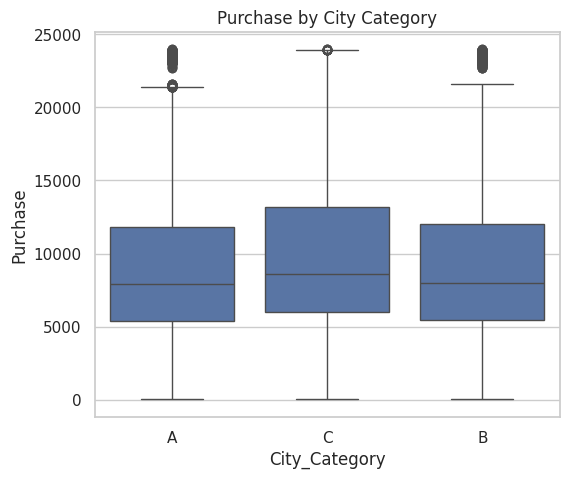

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="City_Category",
    y="Purchase",
    data=df
)

plt.title("Purchase by City Category")

plt.show()

Purchase amounts vary slightly across city categories.

**Correlation Heatmap**

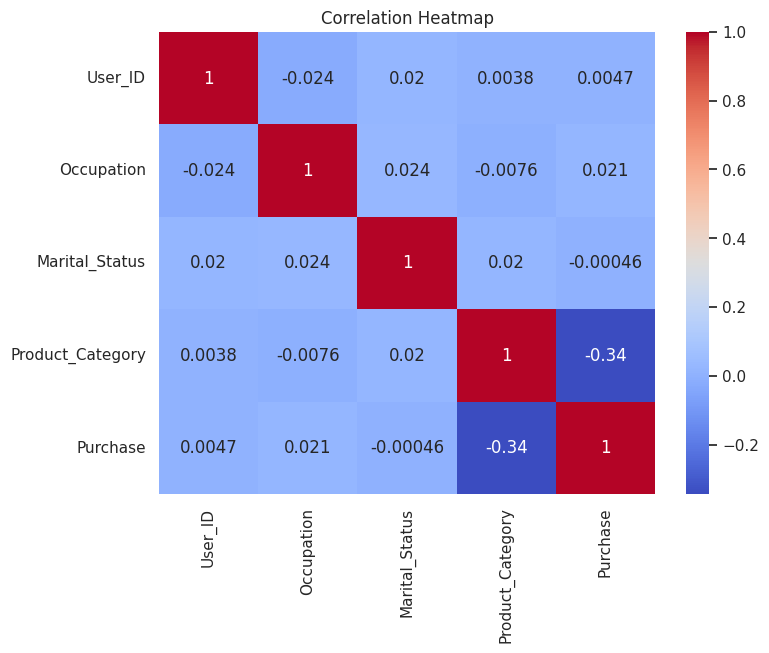

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

No strong linear correlation exists among the variables. Product Category shows the strongest association with Purchase.

**Missing Value & Outlier Detection**

In [ ]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


No missing values are present in the dataset, indicating that the data is complete and suitable for analysis.

**Outlier Detection**

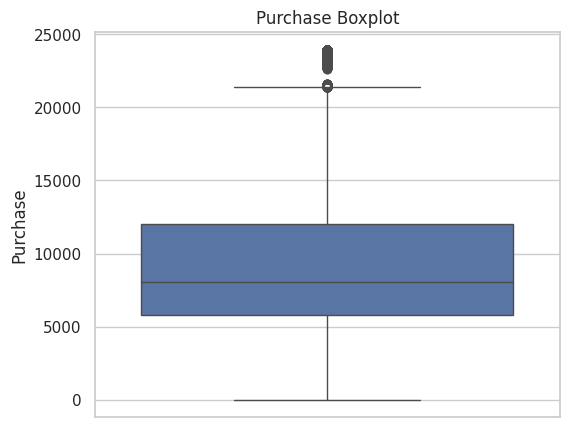

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(y="Purchase", data=df)
plt.title("Purchase Boxplot")
plt.show()

In [ ]:
Q1 = df["Purchase"].quantile(0.25)
Q3 = df["Purchase"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["Purchase"] < lower_limit) | (df["Purchase"] > upper_limit)]

print("Number of Outliers:", len(outliers))
print("Percentage:", round(len(outliers)/len(df)*100,2), "%")

Number of Outliers: 2677
Percentage: 0.49 %


These represent genuine high-value Black Friday purchases rather than data entry errors, so they are retained for further analysis.

Business Insights Based on Non-Graphical & Visual Analysis

**A. Comments on the Range of Attributes**

1.Purchase values range from 12 to 23,961, indicating substantial variation in customer spending.

2.Customers belong to age groups ranging from 0–17 to 55+

3.Occupation codes range from 0 to 20, representing diverse professions.

4.Customers come from three city categories (A, B, and C).

**B. Comments on the Distribution of Variables & Relationships**


1.Male customers slightly outnumber female customers.

2.The 26–35 age group represents the largest customer segment.

3.City Category B contains the highest number of customers.

4.Heatmap analysis indicates no strong linear correlation among numerical variables.

**C. Comments for Each Univariate Plot**

**Purchase Histogram**
Purchase values are positively skewed with a few high-value purchases.

**Gender Countplot**
Male customers are more numerous than female customers.

**Age Countplot**
The 26–35 age group has the highest customer count.

**Occupation Countplot**
Customers belong to a wide variety of occupations.

**City Category Countplot**
City Category B has the highest customer representation.

**Marital Status Countplo**t
Married and unmarried customers are both well represented.

**Purchase Boxplot**
Purchase values contain a small number of high-value outliers.

**D. Comments for Each Bivariate Plot**

**Gender vs Purchase**
Male customers have a slightly higher average purchase than female customers.

**Age vs Purchase**
Customers aged 26–35 tend to spend more than other age groups.

**Marital Status vs Purchase**
Married and unmarried customers exhibit similar spending patterns.

**City Category vs Purchase**
Purchase amounts vary slightly across different city categories.

**Correlation Heatmap**
No strong linear relationships exist among the numerical variables.


**Are women spending more money per transaction than men?**

In [ ]:
df.groupby("Gender")["Purchase"].mean()

,Purchase
Gender,
F,8734.565765
M,9437.526040


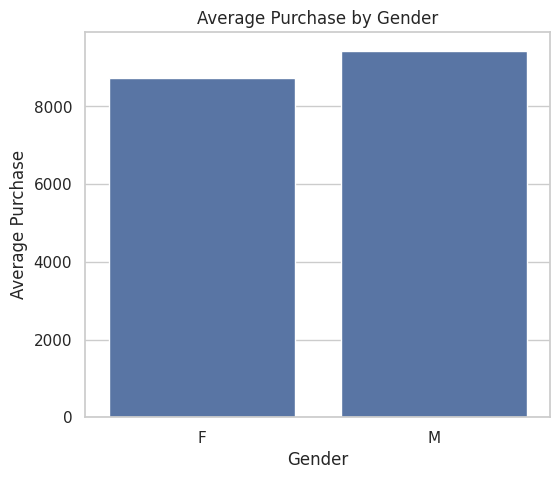

In [ ]:
plt.figure(figsize=(6,5))

sns.barplot(
    x="Gender",
    y="Purchase",
    data=df,
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Purchase by Gender")
plt.ylabel("Average Purchase")

plt.show()


Male customers have a slightly higher average purchase amount than female customers.

Lets also do statistical analysis  to determine  the difference

**Confidence Intervals and Distribution of Mean Expenses**

In [ ]:
from scipy.stats import norm

In [ ]:
male = df[df["Gender"]=="M"]["Purchase"]
female = df[df["Gender"]=="F"]["Purchase"]
male_mean = male.mean()
female_mean = female.mean()

male_std = male.std()
female_std = female.std()

male_n = len(male)
female_n = len(female)
z = norm.ppf(0.975)

male_margin = z * (male_std / np.sqrt(male_n))
female_margin = z * (female_std / np.sqrt(female_n))

male_ci = (
    male_mean - male_margin,
    male_mean + male_margin
)

female_ci = (
    female_mean - female_margin,
    female_mean + female_margin
)

print("Male CI:", male_ci)
print("Female CI:", female_ci)

Male CI: (np.float64(9422.01944736257), np.float64(9453.032633581959))
Female CI: (np.float64(8709.21154714068), np.float64(8759.919983170272))


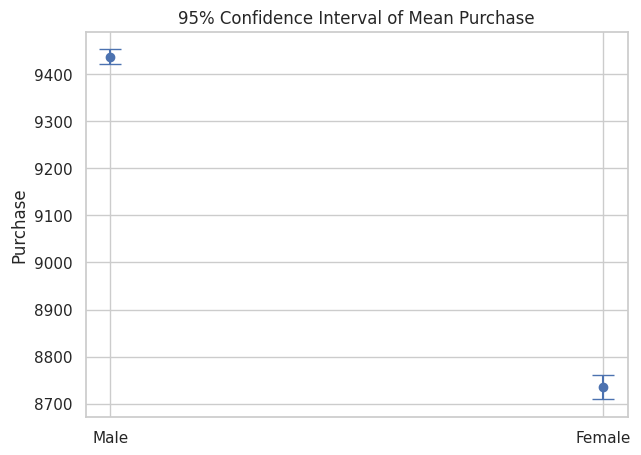

In [ ]:
plt.figure(figsize=(7,5))

plt.errorbar(
    ["Male","Female"],
    [male_mean,female_mean],
    yerr=[male_margin,female_margin],
    fmt='o',
    capsize=8
)

plt.title("95% Confidence Interval of Mean Purchase")

plt.ylabel("Purchase")

plt.show()

The graph shows the average purchase along with the 95% confidence interval.

In [ ]:
if male_ci[0] <= female_ci[1] and female_ci[0] <= male_ci[1]:
    print("Confidence intervals overlap.")
else:
    print("Confidence intervals do not overlap.")

Confidence intervals do not overlap.


The 95% confidence intervals for male and female customers do not overlap

***How can Walmart leverage this conclusion?***

Walmart can design gender-specific marketing campaigns to improve customer engagement.


Walmart can introduce personalized discounts, loyalty programs, or bundled offers for female customers to encourage higher spending.



In [ ]:
married = df[df["Marital_Status"]==1]["Purchase"]

unmarried = df[df["Marital_Status"]==0]["Purchase"]
married_mean = married.mean()
unmarried_mean = unmarried.mean()

married_std = married.std()
unmarried_std = unmarried.std()

married_n = len(married)
unmarried_n = len(unmarried)
married_margin = z * (married_std/np.sqrt(married_n))

unmarried_margin = z * (unmarried_std/np.sqrt(unmarried_n))

married_ci = (
    married_mean-married_margin,
    married_mean+married_margin
)

unmarried_ci = (
    unmarried_mean-unmarried_margin,
    unmarried_mean+unmarried_margin
)

print(married_ci)

print(unmarried_ci)

(np.float64(9240.460427057078), np.float64(9281.888721107669))
(np.float64(9248.61641818668), np.float64(9283.198819656332))


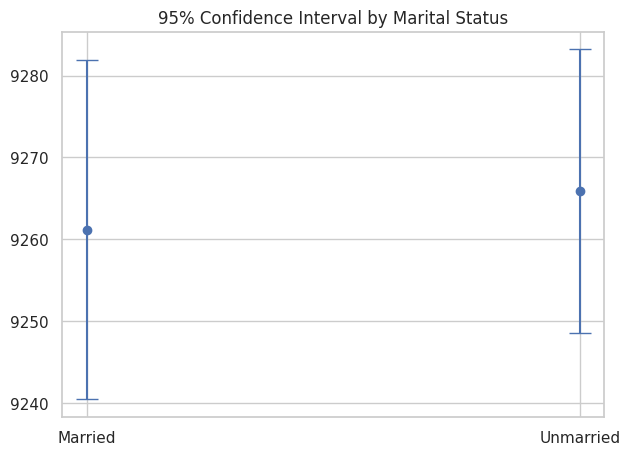

In [ ]:
plt.figure(figsize=(7,5))

plt.errorbar(
    ["Married","Unmarried"],
    [married_mean,unmarried_mean],
    yerr=[married_margin,unmarried_margin],
    fmt='o',
    capsize=8
)

plt.title("95% Confidence Interval by Marital Status")

plt.show()

In [ ]:
# Check overlap
if married_ci[0] <= unmarried_ci[1] and unmarried_ci[0] <= married_ci[1]:
    print("The confidence intervals overlap.")

else:
    print("The confidence intervals do not overlap.")


The confidence intervals overlap.


**Observation**

The 95% confidence intervals of married and unmarried customers overlap.

This indicates that the average spending of married and unmarried customers is similar.


**Business Insight**

Walmart should not create separate pricing or promotional strategies based solely on marital status.

Marketing efforts should instead focus on factors such as age, product preferences, shopping history, and customer segmentation

**Age-wise Analysis**

In [ ]:
df["Age_Group"] = df["Age"].replace({
    "36-45":"36-50",
    "46-50":"36-50",
    "51-55":"51+",
    "55+":"51+"
})

age_order = ["0-17","18-25","26-35","36-50","51+"]
age_mean=[]

age_margin=[]

for age in age_order:

    sample=df[df["Age_Group"]==age]["Purchase"]

    mean=sample.mean()

    std=sample.std()

    n=len(sample)

    margin=z*(std/np.sqrt(n))

    age_mean.append(mean)

    age_margin.append(margin)

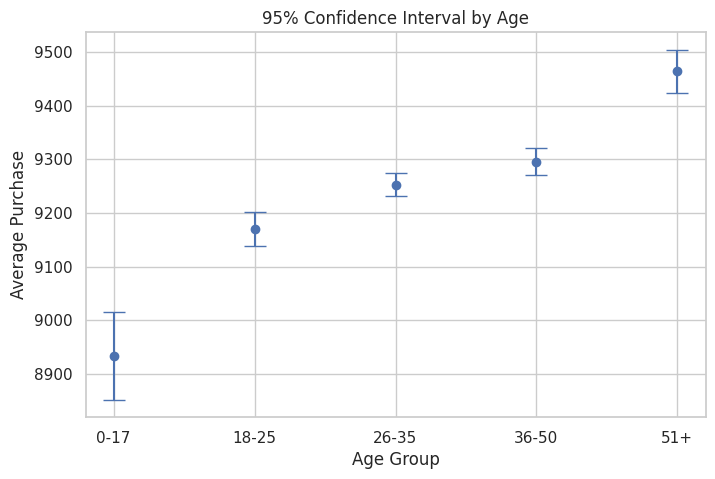

In [ ]:
plt.figure(figsize=(8,5))

plt.errorbar(
    age_order,
    age_mean,
    yerr=age_margin,
    fmt='o',
    capsize=8
)

plt.title("95% Confidence Interval by Age")

plt.xlabel("Age Group")

plt.ylabel("Average Purchase")

plt.show()

In [ ]:
for i in range(len(age_order)-1):

    lower1 = age_mean[i]-age_margin[i]
    upper1 = age_mean[i]+age_margin[i]

    lower2 = age_mean[i+1]-age_margin[i+1]
    upper2 = age_mean[i+1]+age_margin[i+1]

    if lower1<=upper2 and lower2<=upper1:

        print(age_order[i],"and",age_order[i+1],"Overlap")

    else:

        print(age_order[i],"and",age_order[i+1],"Do Not Overlap")

0-17 and 18-25 Do Not Overlap
18-25 and 26-35 Do Not Overlap
26-35 and 36-50 Overlap
36-50 and 51+ Do Not Overlap


Since the 26–35 age group overlaps with every other group, it represents a broad customer segment whose spending behavior is comparable across multiple age categories.

Walmart should continue targeting the 26–35 segment with general promotions, as it is also one of the largest customer groups.



Age-based customer segmentation can help improve customer engagement and maximize sales.

**Final Insights (10 Marks)**

**1. Insights Based on Exploratory Data Analysis (EDA)**

The dataset contains complete information with no missing values, making it reliable for analysis.

Purchase amounts are positively skewed, meaning most customers make low-to-medium purchases while only a few make very high-value purchases.

Male customers slightly outnumber female customers in the dataset.

The 26–35 age group represents the largest customer segment and contributes significantly to overall sales.



**2. Insights Based on the Central Limit Theorem (Confidence Intervals**)

The large sample size makes the estimated average purchase values reliable for representing the overall customer population.

The confidence intervals provide a good estimate of the average spending of different customer groups.

The confidence intervals for male and female customers do not overlap, indicating a significant difference in their average spending.

The confidence intervals for married and unmarried customers overlap,
suggesting similar spending behaviour.

The 26–35 age group overlaps with all other age groups, while the remaining age groups show significant differences in spending patterns.



**Recommendations**

Continue targeting the 26–35 age group with attractive offers, as it is one of the largest and most valuable customer segments.

Develop personalized marketing campaigns based on customer age and shopping preferences instead of using a one-size-fits-all approach.



Use gender-based promotions where appropriate, since male customers show higher average spending in this analysis.

Expand loyalty and reward programs to encourage repeat purchases across all customer groups.

Use customer purchase history to recommend relevant products and improve the shopping experience.

Continue offering promotions across all city categories while tailoring product availability based on local customer demand.

Monitor high-value purchases to identify premium customer segments and provide exclusive offers.

Regularly analyze customer purchasing patterns before major shopping events to improve inventory planning and marketing strategies.